# Anatomy of Engine Divergence

**Docker image**: `ml4t`

Backtesting frameworks make implicit execution decisions - fill ordering,
share rounding, cash management - that produce different P&L from identical
signals. This notebook makes those differences *visible* using ml4t-backtest's
configurable `BacktestConfig`, then compares against VectorBT.

**Learning Objectives**:
- Test when fill ordering (exit-first vs FIFO) changes P&L on identical signals
- Diagnose when integer sizing changes allocations or trade counts
- Quantify the impact of commission headroom on capital efficiency
- Diagnose which execution mechanics matter at a given portfolio scale

**Book Reference**: Chapter 16, Section 16.3 (Backtesting Engine Comparison)

**Prerequisites**: Complete [`06_linear`](../case_studies/etfs/06_linear.ipynb) (prediction artifacts).

In [1]:
"""Anatomy of Engine Divergence - how execution mechanics change backtest results."""

import copy
from datetime import datetime

import matplotlib.pyplot as plt
import polars as pl
from ml4t.backtest import BacktestConfig, DataFeed, Engine
from ml4t.backtest.config import (
    CommissionType,
    ExecutionMode,
    ExecutionPrice,
    FillOrdering,
    RebalanceMode,
    ShareType,
    SlippageType,
)
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from validation.adapters.ml4t_adapter import (
    PrecomputedWeightStrategy,
    _align_prices_to_weight_window,
    _convert_result,
    _filter_late_assets,
)
from validation.adapters.vectorbt_adapter import run_vectorbt
from validation.weights import load_case_study_data

from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
CASE_STUDY = "etfs"
LABEL = "fwd_ret_21d"
INITIAL_CASH = 1_000_000

## 1. Load Shared Data

We reuse validation predictions from the ETF linear model pipeline. Before
portfolio formation, we fix the tradable universe to assets with price
history at the first signal date. The rebuilt weights then feed every engine
configuration, isolating execution mechanics from signal-generation choices.

In [3]:
prices, signals, initial_weights, meta = load_case_study_data(CASE_STUDY, LABEL)
cost_rate = meta["cost_bps"] / 10_000

if initial_weights.empty:
    raise RuntimeError(
        "No validation weights were produced for this case study. "
        "Run the prerequisite prediction pipeline before executing this notebook."
    )

print(f"Case Study: {meta['case_study']}")
print(f"Label: {meta['label']} (pre-computed linear validation predictions)")
print(f"Signal universe: {meta['n_assets']} assets, {meta['n_signal_dates']} signal dates")
print(f"Cost: {meta['cost_bps']} bps ({cost_rate:.4f})")
print(f"Period: {initial_weights.index[0].date()} to {initial_weights.index[-1].date()}")

Case Study: etfs
Label: fwd_ret_21d (pre-computed linear validation predictions)
Signal universe: 99 assets, 2016 signal dates
Cost: 10 bps (0.0010)
Period: 2015-12-28 to 2023-12-29


### Prepare Engine Infrastructure

`form_tie_aware_weights` makes the ranking policy explicit. An all-equal
prediction cross-section contains no ranking information, so every asset in
the fixed tradable universe receives equal weight. Otherwise, predictions
rank from high to low and `symbol` ascending is the stable secondary key,
including when a tie crosses the quintile cutoff.

In [4]:
def select_cross_section(cross_section, tradable_assets):
    """Select one cross-section using the disclosed deterministic tie policy."""
    ranked = cross_section.sort(["prediction", "symbol"], descending=[True, False])
    top_n = max(1, ranked.height // 5)
    if ranked["prediction"].n_unique() == 1:
        return tradable_assets, True, False

    cutoff = ranked["prediction"][top_n - 1]
    above = ranked.filter(pl.col("prediction") > cutoff).height
    at_or_above = ranked.filter(pl.col("prediction") >= cutoff).height
    cutoff_tie = above < top_n < at_or_above
    return ranked["symbol"].head(top_n).to_list(), False, cutoff_tie

In [5]:
def form_tie_aware_weights(signals, tradable_assets, min_assets):
    """Apply a permutation-invariant cross-sectional selection policy."""
    selections = []
    all_equal_dates = 0
    cutoff_tie_dates = 0
    for timestamp in signals["timestamp"].unique().sort():
        cross_section = signals.filter(pl.col("timestamp") == timestamp)
        if cross_section.height < min_assets:
            continue
        selected, all_equal, cutoff_tie = select_cross_section(cross_section, tradable_assets)
        all_equal_dates += int(all_equal)
        cutoff_tie_dates += int(cutoff_tie)
        weight = 1.0 / len(selected)
        selections.append(
            pl.DataFrame(
                {"timestamp": [timestamp] * len(selected), "symbol": selected}
            ).with_columns(pl.lit(weight).alias("weight"))
        )
    selected_long = pl.concat(selections)
    weights = selected_long.pivot(on="symbol", index="timestamp", values="weight").sort("timestamp")
    missing = [symbol for symbol in tradable_assets if symbol not in weights.columns]
    weights = weights.with_columns(*(pl.lit(0.0).alias(symbol) for symbol in missing))
    weights_pd = weights.select("timestamp", *tradable_assets).to_pandas().set_index("timestamp")
    return weights_pd.fillna(0.0), all_equal_dates, cutoff_tie_dates

`build_tradable_weights` fixes the common price universe before applying that
policy. It then removes floating-point residue through a stable symbol anchor
so every executable baseline row is fully invested.

In [6]:
def build_tradable_weights(prices, signals, seed_weights, min_assets):
    """Fix the tradable universe before portfolio formation and normalize each row."""
    prices_f, seed_weights_f = _filter_late_assets(prices, seed_weights)
    tradable_assets = sorted(prices_f["symbol"].unique().to_list())
    signals_f = signals.filter(pl.col("symbol").is_in(tradable_assets))
    weights_f, all_equal_dates, cutoff_tie_dates = form_tie_aware_weights(
        signals_f, tradable_assets, min_assets
    )
    weights_f = weights_f.div(weights_f.sum(axis=1), axis=0)

    residual = 1.0 - weights_f.sum(axis=1)
    for timestamp, adjustment in residual.items():
        anchor = weights_f.loc[timestamp][weights_f.loc[timestamp] > 0].index[0]
        weights_f.at[timestamp, anchor] += adjustment

    removed_assets = sorted(set(seed_weights.columns) - set(seed_weights_f.columns))
    prices_f, weights_f = _align_prices_to_weight_window(prices_f, weights_f)
    tie_policy = {"all_equal": all_equal_dates, "cutoff_ties": cutoff_tie_dates}
    return prices_f, weights_f, removed_assets, tie_policy

The fixed universe excludes XLC before selection. The audit below is
executable: every baseline row must sum to exactly 1.0.

In [7]:
prices_f, weights_f, removed_assets, tie_policy = build_tradable_weights(
    prices, signals, initial_weights, meta["min_assets"]
)
baseline_weight_sums = weights_f.sum(axis=1)
if not baseline_weight_sums.eq(1.0).all():
    raise RuntimeError("Tradable-universe target weights are not fully invested")

print(f"Comparison universe: {weights_f.shape[1]} assets")
print(f"Excluded late starters: {', '.join(removed_assets) if removed_assets else 'none'}")
print(f"Executable window: {weights_f.index[0].date()} to {weights_f.index[-1].date()}")
print(f"All-equal dates using the full universe: {tie_policy['all_equal']}")
print(f"Cutoff ties resolved by symbol: {tie_policy['cutoff_ties']}")
print(
    f"Baseline allocation range: {baseline_weight_sums.min():.6f} "
    f"to {baseline_weight_sums.max():.6f}"
)

Comparison universe: 99 assets
Excluded late starters: XLC
Executable window: 2015-12-28 to 2023-12-29
All-equal dates using the full universe: 504
Cutoff ties resolved by symbol: 0
Baseline allocation range: 1.000000 to 1.000000


`run_with_config` wires a `BacktestConfig` through the precomputed-weights
strategy and returns a standardized result; downstream cells call it with
different configs to isolate one execution mechanic at a time.

In [8]:
def run_with_config(config, target_weights=weights_f):
    """Run ml4t-backtest with explicit BacktestConfig and return BacktestResult."""
    allow_frac = config.share_type == ShareType.FRACTIONAL
    rebalance_cfg = RebalanceConfig(
        allow_fractional=allow_frac,
        min_trade_value=0.0,
        min_weight_change=0.0,
        rebalance_mode=config.rebalance_mode,
    )

    weight_dict: dict[datetime, dict[str, float]] = {}
    for ts in target_weights.index:
        ts_dt = ts.to_pydatetime() if hasattr(ts, "to_pydatetime") else ts
        row = target_weights.loc[ts]
        w = {c: float(row[c]) for c in target_weights.columns if row[c] > 0}
        if w:
            weight_dict[ts_dt] = w

    executor = TargetWeightExecutor(config=rebalance_cfg)
    strategy = PrecomputedWeightStrategy(weight_dict, executor)
    feed = DataFeed(prices_df=prices_f)
    engine = Engine.from_config(feed, strategy, config)
    result = engine.run()
    return _convert_result(result, config.preset_name or "custom", config.initial_cash)

`metrics_row` extracts the comparable fields from a `BacktestResult` for the
DataFrame summaries that appear after each comparison.

In [9]:
def metrics_row(r):
    """Extract key metrics from a BacktestResult."""
    return {
        "final_value": round(r.final_value),
        "return_pct": round(r.total_return * 100, 2),
        "sharpe": round(r.metrics.get("sharpe", 0), 3),
        "max_dd_pct": round(abs(r.metrics.get("max_drawdown", 0)) * 100, 2),
        "trades": r.n_trades,
        "commission": round(r.metrics.get("total_commission", 0)),
    }

## 2. Controlled Reference Configuration

The reference uses next-bar open fills, fractional shares, exit-first ordering,
snapshot rebalancing, and percentage commission. Every field is explicit so a
future library-preset change cannot silently alter the experiment. Slippage is
disabled so each variant changes only its named execution mechanic.

In [10]:
def make_reference():
    """Create the explicit controlled-reference configuration."""
    config = BacktestConfig.from_preset("default")
    config.initial_cash = INITIAL_CASH
    config.commission_type = CommissionType.PERCENTAGE
    config.commission_rate = cost_rate
    config.slippage_type = SlippageType.NONE
    config.slippage_rate = 0.0
    config.execution_mode = ExecutionMode.NEXT_BAR
    config.execution_price = ExecutionPrice.OPEN
    config.share_type = ShareType.FRACTIONAL
    config.fill_ordering = FillOrdering.EXIT_FIRST
    config.rebalance_mode = RebalanceMode.SNAPSHOT
    return config


baseline_config = make_reference()
r_baseline = run_with_config(baseline_config)

print("Controlled reference:")
print(f"  Final Value:  ${r_baseline.final_value:,.0f}")
print(f"  Total Return: {r_baseline.total_return:.2%}")
print(f"  Sharpe:       {r_baseline.metrics.get('sharpe', 0):.3f}")
print(f"  Max Drawdown: {r_baseline.metrics.get('max_drawdown', 0):.2%}")
print(f"  Trades:       {r_baseline.n_trades:,}")

Controlled reference:
  Final Value:  $2,131,006
  Total Return: 113.10%
  Sharpe:       0.616
  Max Drawdown: 30.58%
  Trades:       77,586


## 3. Fill Ordering: EXIT_FIRST vs FIFO

When a rebalance requires both sells and buys, the engine must decide
which orders to process first:

- **EXIT_FIRST**: Sells execute before buys, freeing cash for purchases.
  The buy-side has more capital available, potentially filling larger orders.
- **FIFO**: Orders execute in submission order. If early buys consume cash,
  later buys may be rejected for insufficient funds.

Same signals, same shares, same timing - only the processing sequence differs.

In [11]:
fifo_config = make_reference()
fifo_config.fill_ordering = FillOrdering.FIFO

r_fifo = run_with_config(fifo_config)

# Compare
table = pl.DataFrame(
    [
        {"config": "EXIT_FIRST (baseline)", **metrics_row(r_baseline)},
        {"config": "FIFO", **metrics_row(r_fifo)},
    ]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""EXIT_FIRST (baseline)""",2131006,113.1,0.616,30.58,77586,183117
"""FIFO""",2131006,113.1,0.616,30.58,77586,183117


In [12]:
eq_base = r_baseline.equity_curve
eq_fifo = r_fifo.equity_curve
common = eq_base.index.intersection(eq_fifo.index)

diff_pct = (eq_base.loc[common] - eq_fifo.loc[common]) / eq_base.loc[common] * 100
val_diff = r_baseline.final_value - r_fifo.final_value
ordering_gap_bps = val_diff / r_baseline.final_value * 10_000

The upper panel compares portfolio value; the lower panel makes the small
pathwise gap visible around a zero reference.


Final value difference: $0 (0.000%)
Trade count: 77,586 vs 77,586 (delta: 0)


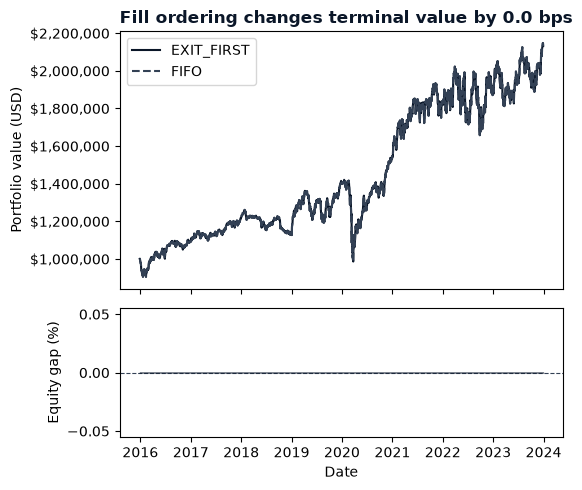

In [13]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], height_ratios=[2, 1], sharex=True)

axes[0].plot(
    eq_base.loc[common].index,
    eq_base.loc[common].values,
    color=COLORS["blue"],
    label="EXIT_FIRST",
)
axes[0].plot(
    eq_fifo.loc[common].index,
    eq_fifo.loc[common].values,
    color=COLORS["neutral"],
    label="FIFO",
    linestyle="--",
)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
add_message_title(
    axes[0], f"Fill ordering changes terminal value by {abs(ordering_gap_bps):.1f} bps"
)
axes[0].set_title(axes[0].get_title(loc="left"), loc="left", fontweight="bold")

axes[1].fill_between(common, diff_pct.values, alpha=0.5, color=COLORS["blue"])
zero_line(axes[1])
axes[1].set_ylabel("Equity gap (%)")
axes[1].set_xlabel("Date")

fig.tight_layout()
fig.show()

print(f"\nFinal value difference: ${val_diff:,.0f} ({val_diff / r_baseline.final_value:.3%})")
print(
    f"Trade count: {r_baseline.n_trades:,} vs {r_fifo.n_trades:,} "
    f"(delta: {r_baseline.n_trades - r_fifo.n_trades:,})"
)

With fractional shares and snapshot target computation, the target-weight
executor submits reductions before increases. The broker's fill-order setting
acts only after that submission sequence, so the displayed gap may be zero
even though the configuration values differ.

Fill ordering matters when **integer shares** constrain capital allocation:
an early buy may consume cash needed for a later buy, causing rejection.
EXIT_FIRST avoids this by freeing sell proceeds first. The combined-profile
comparison below changes integer sizing, ordering, and headroom together;
its interaction term should not be assigned to any one lever.

## 4. Share Type: Fractional vs Integer

Fractional shares allow exact target-weight allocation. Integer shares
introduce two effects:

1. **Rounding deviation**: Each trade is rounded to the nearest whole share,
   leaving a small positive or negative deviation from its target weight.
2. **Skipped trades**: When the target delta rounds to zero shares,
   no order is submitted, so the portfolio drifts from its target.

At \$1M, ranked dates hold the top quintile while all-equal dates hold the
full universe. Whole-share rounding is therefore small relative to each
allocation at this portfolio scale.

In [14]:
integer_config = make_reference()
integer_config.share_type = ShareType.INTEGER

r_integer = run_with_config(integer_config)

table = pl.DataFrame(
    [
        {"config": "Fractional (baseline)", **metrics_row(r_baseline)},
        {"config": "Integer", **metrics_row(r_integer)},
    ]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Fractional (baseline)""",2131006,113.1,0.616,30.58,77586,183117
"""Integer""",2122080,112.21,0.612,30.59,63528,187158


In [15]:
eq_int = r_integer.equity_curve
common_int = eq_base.index.intersection(eq_int.index)

diff_int = (eq_base.loc[common_int] - eq_int.loc[common_int]) / eq_base.loc[common_int] * 100
val_diff_int = r_baseline.final_value - r_integer.final_value
integer_gap_bps = val_diff_int / r_baseline.final_value * 10_000

Matching axes show whether integer quantization changes the equity path, while
the gap panel exposes differences hidden by the portfolio-value scale.


Final value difference: $8,927 (0.419%)
Trade count: 77,586 vs 63,528 (delta: 14,058)


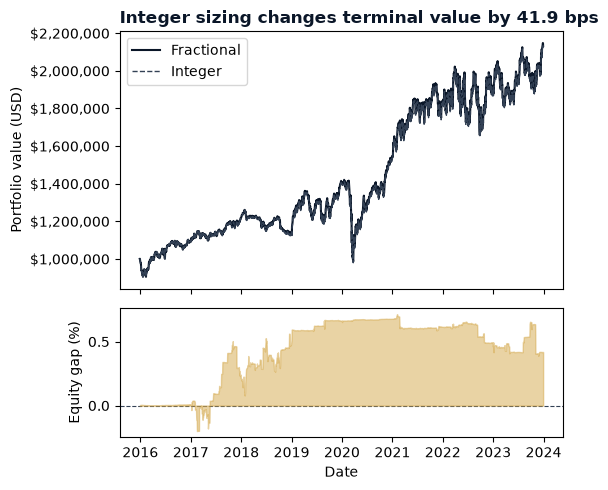

In [16]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], height_ratios=[2, 1], sharex=True)

axes[0].plot(
    eq_base.loc[common_int].index,
    eq_base.loc[common_int].values,
    color=COLORS["blue"],
    label="Fractional",
)
axes[0].plot(
    eq_int.loc[common_int].index,
    eq_int.loc[common_int].values,
    label="Integer",
    color=COLORS["neutral"],
    linewidth=1,
    linestyle="--",
)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
add_message_title(
    axes[0], f"Integer sizing changes terminal value by {abs(integer_gap_bps):.1f} bps"
)
axes[0].set_title(axes[0].get_title(loc="left"), loc="left", fontweight="bold")

axes[1].fill_between(common_int, diff_int.values, alpha=0.5, color=COLORS["amber"])
zero_line(axes[1])
axes[1].set_ylabel("Equity gap (%)")
axes[1].set_xlabel("Date")

fig.tight_layout()
fig.show()

print(
    f"\nFinal value difference: ${val_diff_int:,.0f} ({val_diff_int / r_baseline.final_value:.3%})"
)
print(
    f"Trade count: {r_baseline.n_trades:,} vs {r_integer.n_trades:,} "
    f"(delta: {r_baseline.n_trades - r_integer.n_trades:,})"
)

**Reading the table.** The integer-share row shows two effects relative to
the fractional baseline: a final-value gap (positive or negative depending
on the regime; see the printed numbers above) and a trade-count delta.

Integer sizing rounds each trade to the nearest share, so its deviation can
fall on either side of the exact target. A fractional delta below half a
share becomes no integer order, while a delta above that boundary becomes a
one-share order. Whether the gap is negligible or material depends on
portfolio size relative to share prices; the displayed table is the source
of truth for this run.

## 5. Commission Headroom

Some frameworks (notably Backtrader) reject orders when the portfolio
lacks sufficient cash to cover both the order and its commission.
The workaround: multiply every fully invested target row by 0.998, leaving
exactly 0.2% target-weight headroom. This prevents rejection but creates
systematic under-investment.

In [17]:
HEADROOM = 0.998
weights_headroom = weights_f * HEADROOM
active_headroom_ratio = weights_headroom.where(weights_f > 0).div(weights_f).stack()
headroom_ratio_error = (active_headroom_ratio - HEADROOM).abs().max()
if headroom_ratio_error > 1e-15:
    raise RuntimeError("Commission headroom is not an exact target-weight multiplier")
headroom_weight_sums = weights_headroom.sum(axis=1)

print(
    f"Target allocation: baseline={baseline_weight_sums.min():.3f}-"
    f"{baseline_weight_sums.max():.3f}, headroom={headroom_weight_sums.min():.3f}-"
    f"{headroom_weight_sums.max():.3f}, active-weight ratio={active_headroom_ratio.min():.3f}"
)

r_headroom = run_with_config(make_reference(), target_weights=weights_headroom)

table = pl.DataFrame(
    [
        {"config": "Full allocation (baseline)", **metrics_row(r_baseline)},
        {"config": f"Headroom multiplier ({HEADROOM})", **metrics_row(r_headroom)},
    ]
)
table

Target allocation: baseline=1.000-1.000, headroom=0.998-0.998, active-weight ratio=0.998


config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Full allocation (baseline)""",2131006,113.1,0.616,30.58,77586,183117
"""Headroom multiplier (0.998)""",2121031,112.1,0.613,30.55,78979,187065



Final value difference: $9,975 (0.468%)


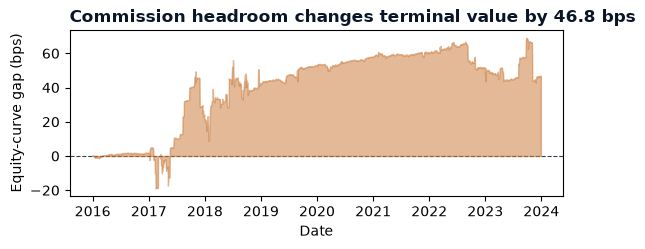

In [18]:
eq_hd = r_headroom.equity_curve
common_hd = eq_base.index.intersection(eq_hd.index)

diff_hd_bps = (eq_base.loc[common_hd] - eq_hd.loc[common_hd]) / eq_base.loc[common_hd] * 10_000
val_diff_hd = r_baseline.final_value - r_headroom.final_value
headroom_gap_bps = val_diff_hd / r_baseline.final_value * 10_000

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.fill_between(common_hd, diff_hd_bps.values, alpha=0.5, color=COLORS["copper"])
zero_line(ax)
ax.set_ylabel("Equity-curve gap (bps)")
ax.set_xlabel("Date")
add_message_title(
    ax, f"Commission headroom changes terminal value by {abs(headroom_gap_bps):.1f} bps"
)
ax.set_title(ax.get_title(loc="left"), loc="left", fontweight="bold")
fig.tight_layout()
fig.show()

print(f"\nFinal value difference: ${val_diff_hd:,.0f} ({val_diff_hd / r_baseline.final_value:.3%})")

**Reading the table.** The headroom buffer creates systematic
under-investment: the fully invested baseline sums to 1.0 on every date, and
the 0.998 multiplier leaves exactly 0.2% target-weight headroom at each
rebalance. That capital participates less in the subsequent return. The compounding
effect is path-dependent and *non-linear* in horizon;
print the final-value gap from the comparison above to see the realized
drag on this run. The headroom is necessary for frameworks like Backtrader
that reject orders when cash is insufficient to cover the trade plus
commission, but it has a measurable cost.

## 6. Combined Execution-Profile Comparison

Each backtesting framework embeds different combinations of these choices.
We compare the explicit controlled reference with the ml4t-backtest profiles
that emulate Backtrader and VectorBT, then run actual VectorBT on exactly the
same filtered prices and weights:

| Profile | Fill Timing | Shares | Fill Order | Headroom |
|--------|-------------|--------|------------|----------|
| Controlled reference | Next-bar open | Fractional | EXIT_FIRST | None |
| `backtrader` | Next-bar open | Integer | FIFO | 0.998 |
| `vectorbt` | Same-bar close | Fractional | EXIT_FIRST | None |


In [19]:
# Backtrader preset
bt_config = BacktestConfig.from_preset("backtrader")
bt_config.initial_cash = INITIAL_CASH
bt_config.commission_rate = cost_rate
bt_config.slippage_type = SlippageType.NONE
bt_config.slippage_rate = 0.0

r_bt = run_with_config(bt_config, target_weights=weights_headroom)

# VectorBT preset (ml4t engine matching VBT behavior)
vbt_config = BacktestConfig.from_preset("vectorbt")
vbt_config.initial_cash = INITIAL_CASH
vbt_config.commission_type = CommissionType.PERCENTAGE
vbt_config.commission_rate = cost_rate
vbt_config.slippage_type = SlippageType.NONE
vbt_config.slippage_rate = 0.0

r_vbt_preset = run_with_config(vbt_config)

In [20]:
# Actual VectorBT engine
r_vbt = run_vectorbt(prices_f, weights_f, initial_cash=INITIAL_CASH, commission_rate=cost_rate)
all_results = [r_baseline, r_bt, r_vbt_preset, r_vbt]
all_labels = ["controlled reference", "backtrader profile", "vectorbt profile", "VectorBT"]
styles = [
    {"color": COLORS["blue"], "linewidth": 1.8},
    {"color": COLORS["neutral"], "linestyle": "--"},
    {"color": COLORS["amber"], "linestyle": "-."},
    {"color": COLORS["copper"], "linestyle": ":"},
]

In [21]:
table = pl.DataFrame(
    [{"config": label, **metrics_row(r)} for r, label in zip(all_results, all_labels, strict=False)]
)
table

config,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""controlled reference""",2131006,113.1,0.616,30.58,77586,183117
"""backtrader profile""",2117793,111.78,0.612,30.55,64308,187035
"""vectorbt profile""",2153083,115.52,0.623,30.34,78778,189420
"""VectorBT""",2223452,122.57,0.649,30.35,74741,173240


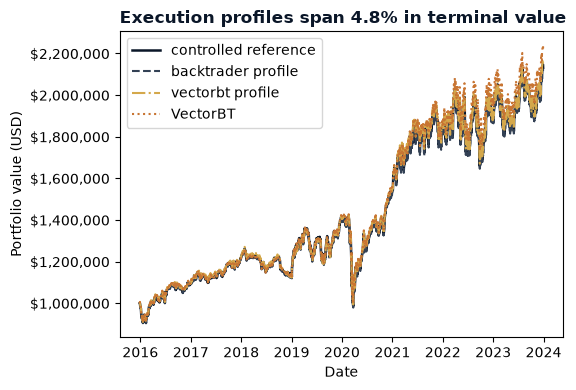

In [22]:
profile_values = [r.final_value for r in all_results]
profile_spread_pct = (max(profile_values) - min(profile_values)) / max(profile_values) * 100
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for r, label, style in zip(all_results, all_labels, styles, strict=False):
    ax.plot(r.equity_curve.index, r.equity_curve.values, label=label, **style)

ax.set_ylabel("Portfolio value (USD)")
ax.set_xlabel("Date")
add_message_title(ax, f"Execution profiles span {profile_spread_pct:.1f}% in terminal value")
ax.set_title(ax.get_title(loc="left"), loc="left", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
fig.tight_layout()
fig.show()

The four equity curves use the same signals but deliberately different
execution profiles. The fresh table is the authority for the current library
version. This is a protocol-sensitivity comparison, not evidence that one
engine is more accurate: each profile answers a different execution question.

## 7. Divergence Decomposition

How much does each execution decision contribute to the total divergence
between the controlled reference and Backtrader profile? We decompose the gap
by measuring each single-variable effect against the baseline.

In [23]:
# Compute individual effects as percentage of baseline final value
baseline_val = r_baseline.final_value
effects = {
    "Fill ordering\n(EXIT_FIRST → FIFO)": (r_baseline.final_value - r_fifo.final_value)
    / baseline_val
    * 100,
    "Share rounding\n(fractional → integer)": (r_baseline.final_value - r_integer.final_value)
    / baseline_val
    * 100,
    "Commission headroom\n(100% → 99.8%)": (r_baseline.final_value - r_headroom.final_value)
    / baseline_val
    * 100,
}

# Combined: controlled reference vs Backtrader profile
combined = (r_baseline.final_value - r_bt.final_value) / baseline_val * 100

labels = list(effects.keys()) + ["Combined\n(reference to Backtrader)"]
values = list(effects.values()) + [combined]
colors = [COLORS["blue"]] * 3 + [COLORS["slate"]]
dominant_effect = max(effects, key=lambda name: abs(effects[name])).split("\n", maxsplit=1)[0]

A horizontal bar chart separates the three one-factor effects from their
combined profile; the interaction is computed immediately afterward.

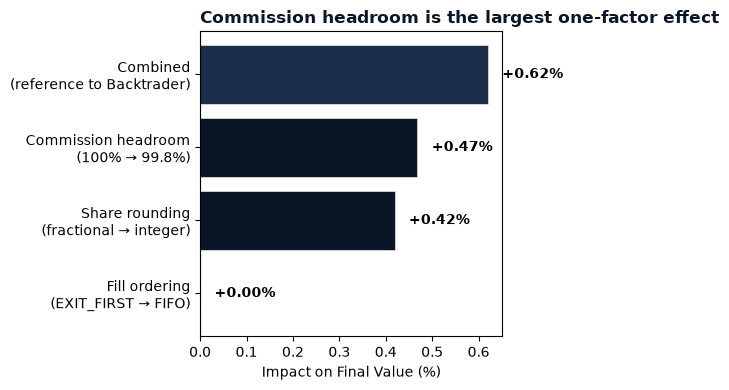

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
bars = ax.barh(labels, values, color=colors, edgecolor=COLORS["silver_muted"], linewidth=0.5)

# Value labels on bars
for bar, val in zip(bars, values, strict=False):
    x = bar.get_width()
    ax.text(
        x + 0.05 * max(abs(v) for v in values),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}%",
        va="center",
        fontweight="bold",
    )

ax.set_xlabel("Impact on Final Value (%)")
add_message_title(ax, f"{dominant_effect} is the largest one-factor effect")
ax.set_title(ax.get_title(loc="left"), loc="left", fontweight="bold")
zero_line(ax, axis="x")
fig.tight_layout()
fig.show()

In [25]:
sum_individual = sum(effects.values())
interaction = combined - sum_individual

print(f"Individual effects sum: {sum_individual:+.2f}%")
print(f"Combined effect:        {combined:+.2f}%")
print(f"Interaction term:       {interaction:+.2f}%")
print("\nThe interaction term shows these effects don't compose linearly.")
print("Integer sizing and commission headroom alter subsequent positions and")
print("cash balances together, so the combined effect differs from their sum.")

Individual effects sum: +0.89%
Combined effect:        +0.62%
Interaction term:       -0.27%

The interaction term shows these effects don't compose linearly.
Integer sizing and commission headroom alter subsequent positions and
cash balances together, so the combined effect differs from their sum.


## 8. Rebalance Mode: Snapshot vs Incremental vs Hybrid

When rebalancing a portfolio of 20+ assets, the engine must decide: **does
each order see the updated portfolio value from prior fills, or do all
orders use a frozen pre-trade snapshot?**

This is not an implementation detail. It reflects a real-world choice about
how brokers process multi-asset rebalances:

| Mode | Target Value | Fills | Real-World Analog |
|------|-------------|-------|-------------------|
| **Snapshot** | Frozen (computed once) | Batched (all at once) | Backtrader, Zipline |
| **Incremental** | Recomputed after each fill | Sequential | Conservative broker |
| **Hybrid** | Frozen for targets | Sequential (cash checked live) | VectorBT |

ml4t-backtest's `BacktestConfig.rebalance_mode` makes this choice explicit.

`run_rebalance_mode` runs the same baseline with a single rebalance-mode
variable swapped, holding share type, fill ordering, and execution mode fixed.

In [26]:
def run_rebalance_mode(mode: RebalanceMode):
    """Run one rebalance mode under an otherwise fixed close-fill profile."""
    config = make_reference()
    config.share_type = ShareType.INTEGER
    config.fill_ordering = FillOrdering.FIFO
    config.execution_mode = ExecutionMode.SAME_BAR
    config.execution_price = ExecutionPrice.CLOSE
    config.rebalance_mode = mode

    rebal_cfg = RebalanceConfig(
        allow_fractional=False,
        min_trade_value=0.0,
        min_weight_change=0.0,
        rebalance_mode=mode,
    )

    weight_dict: dict = {}
    for ts in weights_f.index:
        ts_dt = ts.to_pydatetime() if hasattr(ts, "to_pydatetime") else ts
        row = weights_headroom.loc[ts]
        w = {c: float(row[c]) for c in sorted(weights_headroom.columns) if row[c] > 0}
        if w:
            weight_dict[ts_dt] = w

    executor = TargetWeightExecutor(config=rebal_cfg)
    strategy = PrecomputedWeightStrategy(weight_dict, executor)
    feed = DataFeed(prices_df=prices_f)
    engine = Engine.from_config(feed, strategy, copy.deepcopy(config))
    result = engine.run()
    return _convert_result(result, mode.value, config.initial_cash)


r_snapshot = run_rebalance_mode(RebalanceMode.SNAPSHOT)
r_incremental = run_rebalance_mode(RebalanceMode.INCREMENTAL)
r_hybrid = run_rebalance_mode(RebalanceMode.HYBRID)

In [27]:
table = pl.DataFrame(
    [
        {"mode": "Snapshot (Backtrader-style)", **metrics_row(r_snapshot)},
        {"mode": "Incremental (live value)", **metrics_row(r_incremental)},
        {"mode": "Hybrid (VectorBT-style)", **metrics_row(r_hybrid)},
    ]
)
table

mode,final_value,return_pct,sharpe,max_dd_pct,trades,commission
str,i64,f64,f64,f64,i64,i64
"""Snapshot (Backtrader-style)""",2150068,115.22,0.623,30.29,64221,189073
"""Incremental (live value)""",2150104,115.23,0.623,30.29,64144,188989
"""Hybrid (VectorBT-style)""",2150068,115.22,0.623,30.29,64221,189073


In [28]:
eq_snap = r_snapshot.equity_curve
eq_incr = r_incremental.equity_curve
eq_hybr = r_hybrid.equity_curve
common_rb = eq_snap.index.intersection(eq_incr.index).intersection(eq_hybr.index)
rebalance_values = [r_snapshot.final_value, r_incremental.final_value, r_hybrid.final_value]
rebalance_spread_bps = (
    (max(rebalance_values) - min(rebalance_values)) / max(rebalance_values) * 10_000
)

The upper panel compares the three value paths. The lower panel magnifies the
incremental-minus-snapshot gap on the same dates.

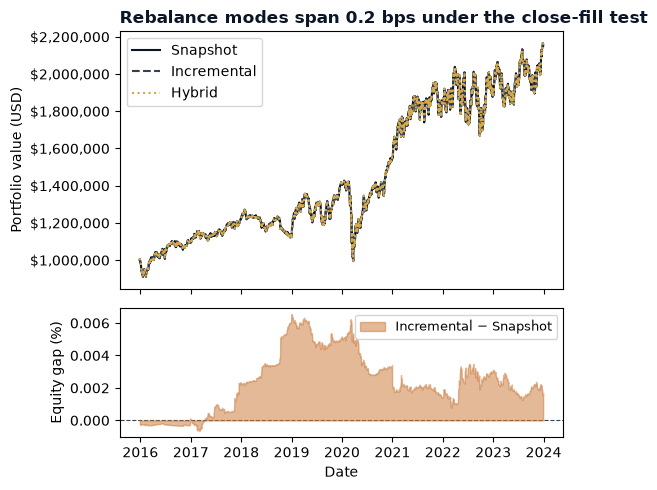

In [29]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], height_ratios=[2, 1], sharex=True)

axes[0].plot(common_rb, eq_snap.loc[common_rb].values, color=COLORS["blue"], label="Snapshot")
axes[0].plot(
    common_rb,
    eq_incr.loc[common_rb].values,
    color=COLORS["neutral"],
    label="Incremental",
    linestyle="--",
)
axes[0].plot(
    common_rb,
    eq_hybr.loc[common_rb].values,
    color=COLORS["amber"],
    label="Hybrid",
    linestyle=":",
)
axes[0].set_ylabel("Portfolio value (USD)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
add_message_title(
    axes[0], f"Rebalance modes span {rebalance_spread_bps:.1f} bps under the close-fill test"
)
axes[0].set_title(axes[0].get_title(loc="left"), loc="left", fontweight="bold")

# Show incremental vs snapshot divergence
diff_is = (eq_incr.loc[common_rb] - eq_snap.loc[common_rb]) / eq_snap.loc[common_rb] * 100
axes[1].fill_between(
    common_rb, diff_is.values, alpha=0.5, color=COLORS["copper"], label="Incremental − Snapshot"
)
zero_line(axes[1])
axes[1].set_ylabel("Equity gap (%)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.show()

In [30]:
pl.DataFrame(
    [
        {"mode": name, "final_value": round(r.final_value), "trades": int(r.n_trades)}
        for name, r in [
            ("Snapshot", r_snapshot),
            ("Incremental", r_incremental),
            ("Hybrid", r_hybrid),
        ]
    ]
)

mode,final_value,trades
str,i64,i64
"""Snapshot""",2150068,64221
"""Incremental""",2150104,64144
"""Hybrid""",2150068,64221


**Reading the table.** This experiment deliberately applies weights computed
with day-$t$ closing information to the same close. That event ordering is not
tradable: the closing price is known only after the order would need to exist.
The resulting returns are therefore a diagnostic counterfactual, not strategy
performance. Holding that invalid chronology fixed still isolates the smaller
implementation differences among snapshot, hybrid, and incremental modes.

**Takeaway**: Establish decision, order, and fill chronology before comparing
backtests. Same-close output cannot validate a close-derived strategy,
regardless of which rebalance mode produces the least-bad curve.

## Key Takeaways

1. **Execution mechanics are design choices, not bugs.** Fill ordering, share
   rounding, cash management, and rebalance mode are deliberate engineering
   decisions that each framework makes differently.

2. **ml4t-backtest makes these explicit** via `BacktestConfig`; readers
   choose their execution assumptions rather than inheriting hidden defaults.

3. **Fill timing determines validity before performance.** A signal computed
   from the close cannot trade at that same close. Treat such output as a
   diagnostic counterfactual, never as an investable backtest.

4. **Share rounding is scale-dependent.** At this portfolio size, the integer
   and fractional configurations track closely. Smaller portfolios and higher
   share prices magnify the target-weight deviation.

5. **Commission headroom compounds.** Cash reserved for fees reduces exposure
   at every rebalance; the table and gap chart quantify the realized effect.

6. **Submission order can neutralize fill order.** Inspect the orders an
   executor creates before attributing a result to the broker's queue policy.

7. **Always document your execution assumptions.** When publishing backtest
   results, specify: fill timing, share type, fill ordering, rebalance mode,
   and cost model. Without this, results are not reproducible.

**Next**: the external-engine parity notebooks make the same execution knobs
concrete on the canonical benchmark:
[`15_lean_engine_parity`](15_lean_engine_parity.ipynb),
[`17_backtrader_zipline_engine_parity`](17_backtrader_zipline_engine_parity.ipynb),
and [`18_vectorbt_engine_parity`](18_vectorbt_engine_parity.ipynb).

**Book**: Section 16.3 covers configurable parity and framework validation.